In this exercise, you will perform 'inpainting' of noisy time series data (which we will just generate artifically). This means performing a regression problem trying to 'guess' what is missing in the middle of a section of data, given only the 'context' at either end.

As the data is noisy, we can not know the exact answer, and outputting a interval is perhaps a better solution. Thus, the task is to estimate not just the average (or median), but both median and upper and lower bounds.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [3]:
#%% #create a noisy time-series generator and a data set class

def generate_time_series(n_steps=50,duration=1,noise_level=0.1,seed=None):
    np.random.seed(seed)
    freq1=0.5
    freq2=1.1
    offset1,offset2 = np.random.rand(2)
    time = np.linspace(0,duration,n_steps)
    series = 0.5*np.sin((time-offset1)*(freq1*10+10))
    series += 0.2*np.sin((time-offset2)*(freq2*20+20))
    series_noisy =series+ noise_level*np.random.randn(n_steps)
    return series_noisy, series

class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self):
        self.duration=1
        self.n_steps = 50*self.duration
        self.noise_level = 0.2

        self.context_size=20
        self.target_size=self.n_steps-self.context_size*2

    def __len__(self):
        return 1000
    def __getitem__(self,idx):
        series_noisy, series_no_noise = generate_time_series(n_steps=self.n_steps,noise_level=self.noise_level,duration=self.duration)

        #split into context and target:
        context_l = torch.tensor(series_noisy[:self.context_size])
        context_r = torch.tensor(series_noisy[-self.context_size:])
        target = torch.tensor(series_noisy[self.context_size:-self.context_size])

        return context_l,context_r,target,series_no_noise


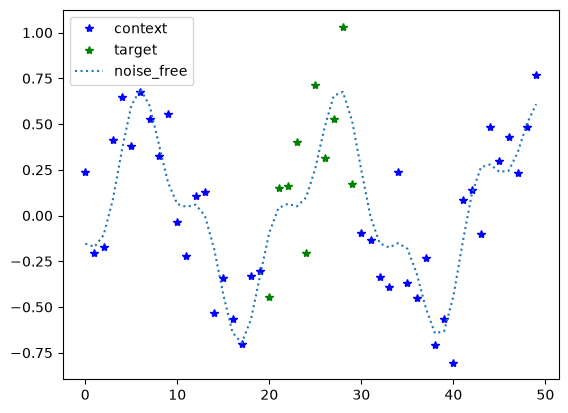

In [4]:
#%% demonstrate the time series generator

dataset=TimeSeriesDataset()
context_l,context_r,target,series_no_noise = dataset[0]

plt.plot(np.arange(len(context_l)),context_l,'b*',label='context')
plt.plot(np.arange(len(context_r))+len(context_r)+len(target),context_r,'*b')
plt.plot(np.arange(len(context_l),len(context_l)+len(target)),target,'*g',label='target')

plt.plot(np.arange(len(series_no_noise)),series_no_noise,':',label='noise_free')

plt.legend()


Set up quantile functions:

In [5]:
# %% loss functions

def quantile_loss(pred, target, quantile):
    """
    Pinball loss for quantile regression
    
    Args:
        pred: predicted values [batch_size, sequence_length]
        target: actual values [batch_size, sequence_length]  
        quantile: quantile level (0 < q < 1), e.g., 0.1, 0.5, 0.9
    """
    # Remove numpy assertions - they don't work with torch tensors
    errors = target - pred
    # Pinball loss: positive errors weighted by q, negative by (1-q)
    loss = torch.max(quantile * errors, (quantile - 1) * errors)
    return loss.mean()


# Convenience: create losses for common quantiles
loss_q10 = lambda pred, tgt: quantile_loss(pred, tgt, quantile=0.1)
loss_q50 = lambda pred, tgt: quantile_loss(pred, tgt, quantile=0.5)
loss_q90 = lambda pred, tgt: quantile_loss(pred, tgt, quantile=0.9)


Exercise:

Train a model to predict the median target as well as the 80% confidence interval. Do this using the quantile loss with different 'quantile' values. It is important that the same model outputs both median and upper and lower boundaries.

In [9]:
# %% multi-quantile network (CORRECTED)
import torch.nn as nn
import torch.nn.functional as F

class QuantileTimeSeriesNet(nn.Module):
    def __init__(self, context_size=20, target_size=10, hidden_size=64):
        super().__init__()
        
        self.context_size = context_size
        self.target_size = target_size  # ← FIXED: Must match dataset
        
        # Input: left + right contexts concatenated
        input_dim = 2 * context_size
        
        # Shared encoder
        self.shared_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
        )
        
        # SINGLE output head that produces ALL 3 quantiles at once
        # Shape: [batch, target_size * 3] -> reshape to [batch, target_size, 3]
        self.output_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, target_size * 3)  # 10 * 3 = 30 outputs
        )
    
    def forward(self, x):
        # x is already concatenated: [batch, 2*context_size]
        encoded = self.shared_encoder(x)
        raw_output = self.output_head(encoded)  # [batch, target_size * 3]
        
        # Reshape: [batch, target_size, 3]
        # Last dimension: [q10, q50, q90]
        return raw_output.reshape(-1, self.target_size, 3)

# Test the model NOW
print("Testing model with correct dimensions...")
model = QuantileTimeSeriesNet()  # Uses target_size=10 from defaults
context_l, context_r, target, _ = dataset[0]
input_tensor = torch.cat((context_l, context_r), axis=0).float().unsqueeze(0)

print(f"Input shape: {input_tensor.shape}")
pred = model(input_tensor)
print(f"Prediction shape: {pred.shape}")
print(f"Target shape: {target.shape}")
print(f"✓ Shapes match!" if pred.shape == (1, target.shape[0], 3) else "✗ Shapes don't match!")

Testing model with correct dimensions...
Input shape: torch.Size([1, 40])
Prediction shape: torch.Size([1, 10, 3])
Target shape: torch.Size([10])
✓ Shapes match!


In [10]:
# %% train model
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = QuantileTimeSeriesNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Create DataLoader
batch_size = 16
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("=" * 70)
print("TRAINING MULTI-QUANTILE MODEL")
print("=" * 70)
print(f"  Quantiles: [0]=q10, [1]=q50(median), [2]=q90")
print(f"  Output shape: [batch, target_size, 3]\n")

for epoch in range(200):
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    
    for ctx_l, ctx_r, target, _ in train_loader:
        # Concatenate contexts to match your interface
        x = torch.cat((ctx_l, ctx_r), dim=1).float().to(device)  # [batch, 2*context_size]
        target = target.to(device)  # [batch, target_size]
        
        optimizer.zero_grad()
        predictions = model(x)  # [batch, target_size, 3]
        
        # Extract each quantile from last dimension
        pred_q10 = predictions[:, :, 0]  # [batch, target_size]
        pred_q50 = predictions[:, :, 1]
        pred_q90 = predictions[:, :, 2]
        
        # Compute quantile losses for each
        q10_loss = quantile_loss(pred_q10, target, quantile=0.1)
        q50_loss = quantile_loss(pred_q50, target, quantile=0.5)
        q90_loss = quantile_loss(pred_q90, target, quantile=0.9)
        
        # Combine losses
        total_loss = q10_loss + q50_loss + q90_loss
        
        total_loss.backward()
        optimizer.step()
        
        epoch_loss += total_loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: Avg Loss = {avg_loss:.4f}")

print("\n✓ Training complete!")

TRAINING MULTI-QUANTILE MODEL
  Quantiles: [0]=q10, [1]=q50(median), [2]=q90
  Output shape: [batch, target_size, 3]

Epoch  50: Avg Loss = 0.1606
Epoch 100: Avg Loss = 0.1587
Epoch 150: Avg Loss = 0.1597
Epoch 200: Avg Loss = 0.1564

✓ Training complete!


Input shape: torch.Size([1, 40])
Model device: cuda:0
Prediction shape: torch.Size([1, 10, 3])
Target shape: torch.Size([10])



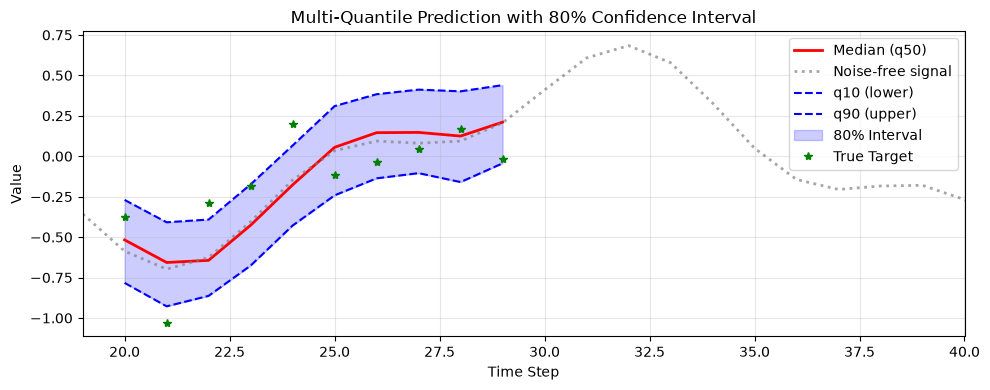

In [14]:
# %% test model - CORRECTED (device-aware)
model.eval()

context_l, context_r, target, series_no_noise = dataset[0]

# Create input and MOVE TO DEVICE
input_tensor = torch.cat((context_l, context_r), dim=0).float()
input_tensor = input_tensor.unsqueeze(0).to(device)  # ← CRITICAL FIX: add .to(device)

# Get predictions
pred = model(input_tensor)  # Should work now!

print(f"Input shape: {input_tensor.shape}")
print(f"Model device: {next(model.parameters()).device}")
print(f"Prediction shape: {pred.shape}")
print(f"Target shape: {target.shape}")
print()

# Plot results
fig, ax = plt.subplots(figsize=(10, 4))

start_idx = len(context_l)
end_idx = start_idx + len(target)

# Median prediction (red line)
ax.plot(np.arange(start_idx, end_idx),
        pred[0, :, 1].detach().cpu().numpy(), 'r-', linewidth=2, label='Median (q50)')

# Clean signal for comparison
ax.plot(series_no_noise, ':', linewidth=2, color='gray', alpha=0.7, label='Noise-free signal')

# Upper and lower bounds (blue lines)
ax.plot(np.arange(start_idx, end_idx),
        pred[0, :, 0].detach().cpu().numpy(), 'b--', linewidth=1.5, label='q10 (lower)')
ax.plot(np.arange(start_idx, end_idx),
        pred[0, :, 2].detach().cpu().numpy(), 'b--', linewidth=1.5, label='q90 (upper)')

# Fill the 80% prediction interval
ax.fill_between(np.arange(start_idx, end_idx),
                pred[0, :, 0].detach().cpu().numpy(),
                pred[0, :, 2].detach().cpu().numpy(),
                color='blue', alpha=0.2, label='80% Interval')

# Target points (green stars)
ax.plot(np.arange(start_idx, end_idx),
        target.detach().cpu().numpy(), '*g', label='True Target')

ax.set_xlim(19, 40)
ax.set_xlabel('Time Step')
ax.set_ylabel('Value')
ax.set_title('Multi-Quantile Prediction with 80% Confidence Interval')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# %% calculate coverage rate across dataset - FIXED
model.eval()

print("Collecting predictions from 200 samples...")
all_preds = []
all_targets = []

with torch.no_grad():
    for idx in range(min(200, len(dataset))):
        context_l, context_r, target, _ = dataset[idx]
        
        # Create input and MOVE TO DEVICE
        input_tensor = torch.cat((context_l, context_r), dim=0).float().unsqueeze(0).to(device)
        
        # Get predictions
        pred = model(input_tensor)
        
        all_preds.append(pred[0].cpu().numpy())  # [target_size, 3]
        all_targets.append(target.cpu().numpy())

all_preds = np.array(all_preds)   # [200, target_size, 3]
all_targets = np.array(all_targets)  # [200, target_size]

print(f"Collected {len(all_preds)} samples\n")

# Coverage: % of true values within [q10, q90] interval
coverage_lower = all_targets >= all_preds[:, :, 0]
coverage_upper = all_targets <= all_preds[:, :, 2]
in_interval = coverage_lower & coverage_upper
coverage_rate = in_interval.mean()

print("=" * 70)
print("COVERAGE EVALUATION")
print("=" * 70)
print(f"  Expected 80% coverage: TRUE values in [q10, q90]")
print(f"  Actual coverage: {coverage_rate*100:.1f}%")
print(f"  Gap: {abs(coverage_rate - 0.8)*100:.1f} percentage points")

if abs(coverage_rate - 0.8) < 0.05:
    print("  ✓ Excellent calibration!")
elif abs(coverage_rate - 0.8) < 0.10:
    print("  ✓ Good calibration")
else:
    print("  ⚠️ Calibration needs adjustment")

print("=" * 70)

Collected 200 samples

COVERAGE EVALUATION
  Expected 80% coverage: TRUE values in [q10, q90]
  Actual coverage: 78.8%
  Gap: 1.3 percentage points
  ✓ Excellent calibration!
